# 03 – Spectrogram Visualization

This notebook explores the frequency representation of MUSDB18 audio signals.

Goals:
- apply the Short-Time Fourier Transform (STFT)
- compute magnitude spectrograms
- compare mixture, vocals and instrumental
- understand the representation later used by the separation model

Imports

In [5]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import stempeg
import librosa
import librosa.display

Config

In [2]:
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from config import TRAIN_DIR, N_FFT, HOP_LENGTH, WIN_LENGTH

Track

In [3]:
track_files = sorted(TRAIN_DIR.glob("*.mp4"))
track_path = track_files[0]

stems, sample_rate = stempeg.read_stems(str(track_path))

mixture = stems[0]
drums = stems[1]
bass = stems[2]
other = stems[3]
vocals = stems[4]

instrumental = drums + bass + other

print(track_path.name)
print(f"Sample rate: {sample_rate} Hz")

A Classic Education - NightOwl.stem.mp4
Sample rate: 44100 Hz


In [4]:
duration = 10

start_sample = 0
end_sample = duration * sample_rate

mixture_segment = mixture[start_sample:end_sample, 0]
vocals_segment = vocals[start_sample:end_sample, 0]
instrumental_segment = instrumental[start_sample:end_sample, 0]

STFT

In [6]:
def compute_spectrogram(audio):
    stft = librosa.stft(
        audio,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH
    )

    magnitude = np.abs(stft)

    return magnitude

Calculate the spectogram

In [7]:
mixture_spec = compute_spectrogram(mixture_segment)
vocals_spec = compute_spectrogram(vocals_segment)
instrumental_spec = compute_spectrogram(instrumental_segment)

print("Mixture:", mixture_spec.shape)
print("Vocals:", vocals_spec.shape)
print("Instrumental:", instrumental_spec.shape)

c:\Users\lithv\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Mixture: (1025, 862)
Vocals: (1025, 862)
Instrumental: (1025, 862)


Convert into db

In [8]:
mixture_db = librosa.amplitude_to_db(
    mixture_spec,
    ref=np.max
)

vocals_db = librosa.amplitude_to_db(
    vocals_spec,
    ref=np.max
)

instrumental_db = librosa.amplitude_to_db(
    instrumental_spec,
    ref=np.max
)

Mix

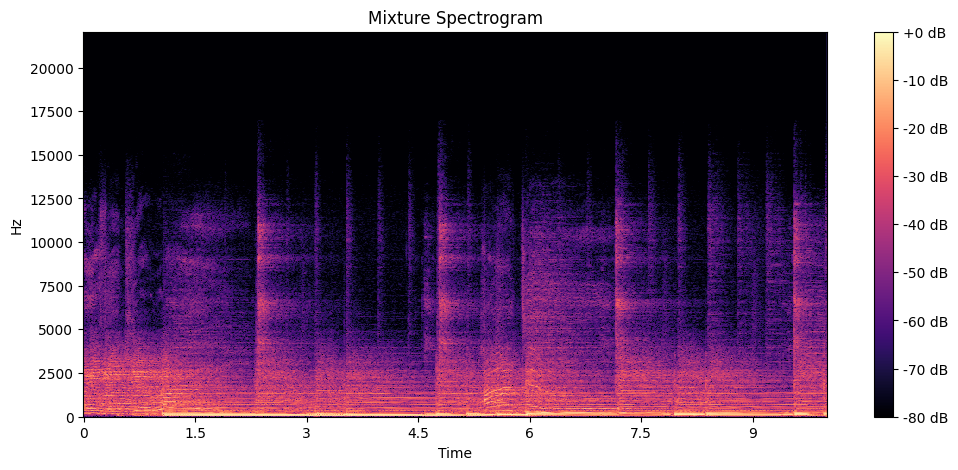

In [9]:
plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mixture_db,
    sr=sample_rate,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Mixture Spectrogram")

plt.show()

Vocals

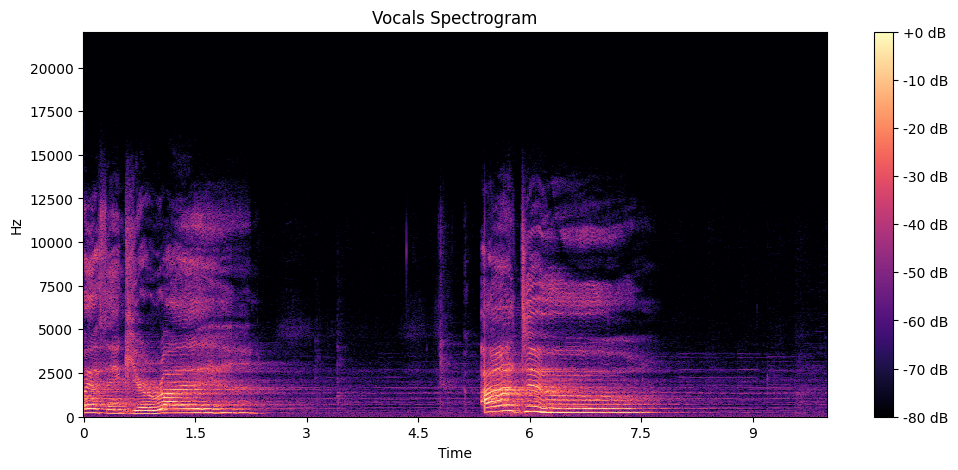

In [10]:
plt.figure(figsize=(12, 5))

librosa.display.specshow(
    vocals_db,
    sr=sample_rate,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Vocals Spectrogram")

plt.show()

Instrumental

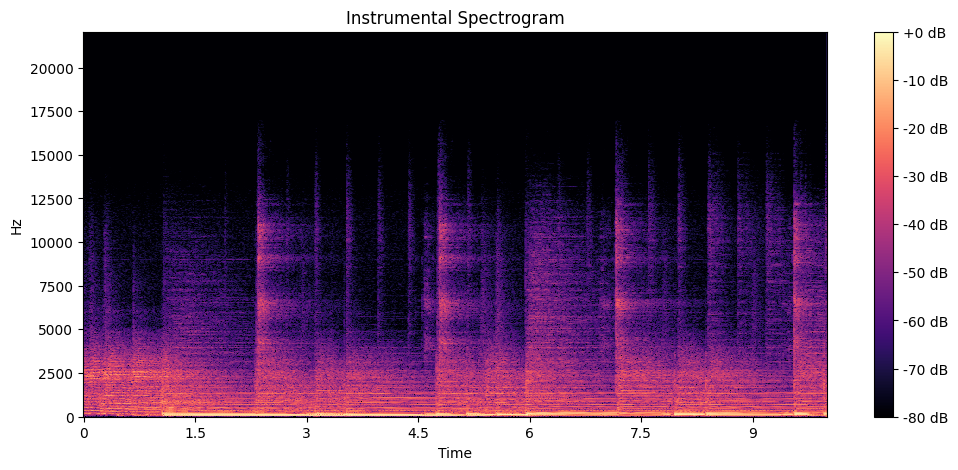

In [11]:
plt.figure(figsize=(12, 5))

librosa.display.specshow(
    instrumental_db,
    sr=sample_rate,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Instrumental Spectrogram")

plt.show()

## Conclusion

The spectrogram representation makes the structure of the audio signals much more visible than the raw waveform.

Mixture, vocals and instrumental contain different time-frequency patterns, but they strongly overlap.

This overlap is the core challenge of music source separation.

The next step is to use these spectrograms as input for a neural network that predicts separation masks for vocals and instrumental.